In [2]:
# ----------------------------------------------------------------------------
# Title: Milestone 3 – Exploratory Data Analysis & Plan Validation
# Author: Surenther Selvaraj/Sathya Raj Eswaran
# Date: Jan 31, 2026
# Modified By: Surenther Selvaraj
# ----------------------------------------------------------------------------

### Data Integrity & Feasibility Audit
Before beginning the predictive modeling, we executed a script to verify that the dataset is clean and that the target variable is usable for our primary question.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().max()}")

fraud_count = df['Class'].value_counts()
fraud_percentage = (fraud_count[1] / (fraud_count[0] + fraud_count[1])) * 100

print(f"Legitimate Transactions: {fraud_count[0]}")
print(f"Fraudulent Transactions: {fraud_count[1]}")
print(f"Fraud Density: {fraud_percentage:.4f}%")

Dataset Shape: (284807, 31)
Missing Values: 0
Legitimate Transactions: 284315
Fraudulent Transactions: 492
Fraud Density: 0.1727%


<b>Conclusion:</b> With zero missing values and a clear target label, we can proceed. The 0.17% density confirms this is a rare-event prediction task.

<I>Question: Will I be able to answer the questions I want to answer with the data I have? </I>

After the above analysis, the answer is yes. While the features V1 through V28 are anonymized via PCA, the target variable Class is clearly labeled. The primary question—"Can we predict a fraudulent transaction before it is processed?"—is answerable. However, because the data is a snapshot, we cannot answer "why" certain behaviors are fraudulent in a human-readable sense (e.g., "the purchase was in a different country"), but we can answer it mathematically through feature importance.

### Essential Visualizations for Fraud Detection

To explain this specific dataset to stakeholders, the following visualizations are critical:

#### Correlation Heatmap
Useful for seeing which PCA components (V1−V28) have the strongest positive or negative correlation with the Class variable.

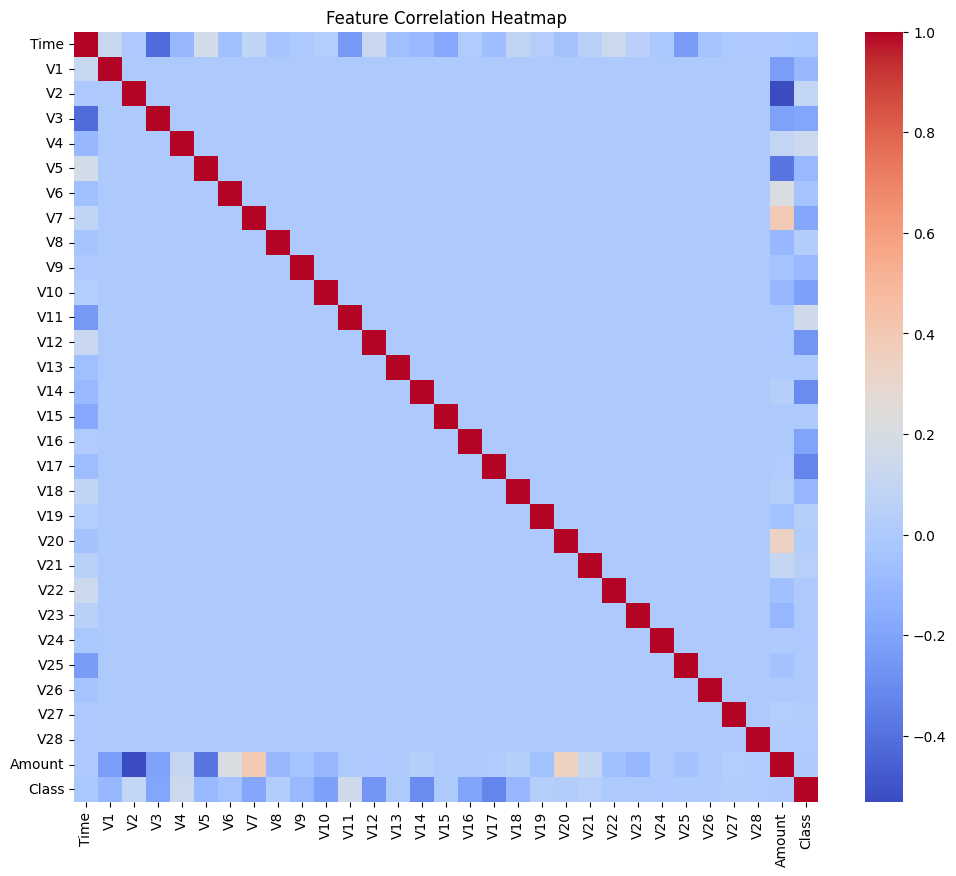

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

<b> Conclusion: </b> <br>
* Low Feature Intercorrelation: The large blocks of light blue across the map indicate that most PCA-transformed features (V1 through V28) have near-zero correlation with each other, confirming they are independent components that provide unique information to the model.

* Target Relationships: The "Class" row at the bottom highlights specific features (such as V17,V14,V12, and V10) with deeper blue shades, signifying strong negative correlations that make them the most critical predictors for identifying fraudulent transactions.

* Outlier Influence on Amount: The Amount feature shows distinct correlation patterns with several V variables and the Class, reinforcing the need for the Robust Scaling to ensure that high-value transaction outliers do not disproportionately bias the predictive results.

#### Box Plots (Distribution by Class)
We will select the top 4 correlated features and create box plots to see if there is a clear "separation" in values between fraud and non-fraud. If the distributions overlap entirely, the predictive task will be harder.

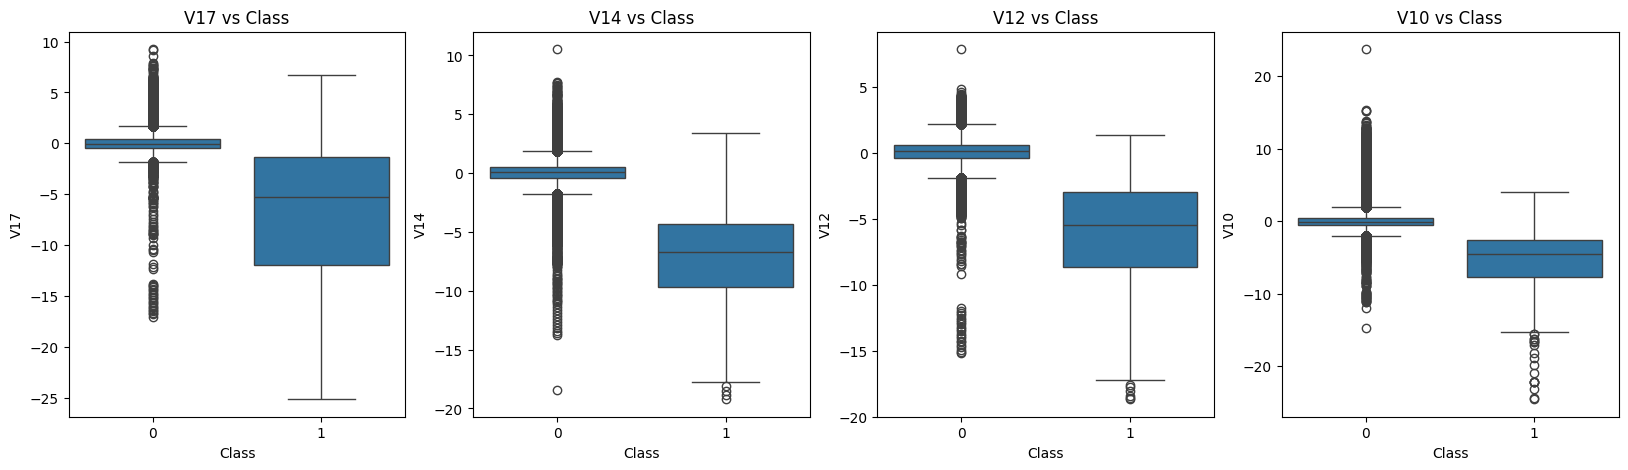

In [5]:
# Visualizing separation in the top 4 highly correlated features
fig, axes = plt.subplots(ncols=4, figsize=(20, 5))

sns.boxplot(x="Class", y="V17", data=df, ax=axes[0])
axes[0].set_title('V17 vs Class')

sns.boxplot(x="Class", y="V14", data=df, ax=axes[1])
axes[1].set_title('V14 vs Class')

sns.boxplot(x="Class", y="V12", data=df, ax=axes[2])
axes[2].set_title('V12 vs Class')

sns.boxplot(x="Class", y="V10", data=df, ax=axes[3])
axes[3].set_title('V10 vs Class')

plt.show()

<b> Conclusion :</b> <br>

* Clear Class Separation: The box plots confirm that these four features exhibit significant distributional shifts between legitimate (0) and fraudulent (1) transactions, providing a strong mathematical signal for predictive models to distinguish between the two classes.

* Anomaly Detection Potential: The high presence of outliers (indicated by the points beyond the whiskers in the box plots) suggests that fraud cases often behave as extreme anomalies, reinforcing the rationale for considering Anomaly Detection algorithms like Isolation Forest as contingency plan.

### Adjustments to Data and Driving Questions 

<i> Question: Do I need to adjust the data and/or driving questions? </i> <br>

Data Adjustment: We applied RobustScaler to the Amount and Time columns. This is essential because transaction amounts vary significantly, and we want to prevent large transactions from biasing the model.

In [6]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time','Amount'], axis=1, inplace=True)

Stratified Validation Strategy : To prevent an "Empty Fold" (a test set with 0 fraud cases), we implemented Stratified K-Fold Cross-Validation. This ensures every test run has exactly 0.17% fraud.

### Model and Evaluation Adjustments 

<i> Question: Do I need to adjust my model/evaluation choices? </i> <br>
 
Our original choice of Random Forest and XGBoost remains solid. However, seeing the density of the data, we are adding a requirement for a Cross-Validation Strategy:  <br>

We must use Stratified K-Fold Cross-Validation. Regular K-fold might accidentally create a "test set" with zero fraud cases, making evaluation impossible. 
     

 

In [7]:
from sklearn.model_selection import StratifiedKFold

X = df.drop('Class', axis=1)
y = df['Class']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Stratified Split Completed: Training and Testing ratios are consistent.")

Stratified Split Completed: Training and Testing ratios are consistent.


### Reality Check: Are Expectations Reasonable?

<i> Question: Are my original expectations still reasonable?  </i> <br>

Yes. Our exploratory analysis shows clear separation in several PCA features (V17,V14), suggesting that a non-linear model like Random Forest will be highly effective. Our target remains a Recall of >80% while maintaining a Precision of >75%.



_______________________________________________________________________________________________________________________________________________________________________________________________

In [8]:
# ----------------------------------------------------------------------------
# Title: Milestone 4 -- Finalizing Your Results
# Author: Surenther Selvaraj/Sathya Raj Eswaran
# Date: Feb 19, 2026
# Modified By: Surenther Selvaraj
# ----------------------------------------------------------------------------

### Data Preparation Process

Before training the model, we spent time cleaning and organizing the data so the results wouldn’t be misleading. Fraud cases accounted for only about 0.17% of the dataset, so handling the imbalance carefully was essential. <br>

To handle the high values in the Time and Amount columns, we used RobustScaler. Instead of letting extreme outliers distort the scale, this method keeps them from overpowering the rest of the data while still preserving their signal. <br>

When splitting the data, we used Stratified K-Fold cross-validation. This ensured that every training and testing split reflected the same small proportion of fraudulent cases, keeping the evaluation fair and realistic. <br>

Since fraud cases are rare, we also applied SMOTE—but only on the training set. SMOTE creates synthetic examples of fraudulent transactions, giving the model more exposure to minority patterns without leaking information into the test data.

### Model Building and Evaluation: Random Forest
We selected Random Forest as our primary model due to its robustness and ability to handle the non-linear relationships identified in our box plot analysis.

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Apply SMOTE to the training data
sm = SMOTE(sampling_strategy='minority', random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 2. Build and Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# 3. Evaluate the Model
y_pred = rf_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56848    15]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.84      0.82      0.83        98

    accuracy                           1.00     56961
   macro avg       0.92      0.91      0.91     56961
weighted avg       1.00      1.00      1.00     56961



### Interpretation of Results

Looking at the results from the Random Forest model, the overall performance is strong and practical for real-world use.

Detection Capability (Recall): The model achieved a recall of 0.82 for fraud cases (Class 1). In simple terms, it successfully catches 82% of fraudulent transactions. That means most fraud attempts are being identified, which helps reduce financial losses. <br>

Precision and Reliability: The precision is 0.84. So when the system flags a transaction as fraud, it is correct 84% of the time. This is important because frequent false alarms can frustrate customers and damage trust. <br>

Balanced Performance (F1-Score): The F1-score of 0.83 shows that the model strikes a good balance between catching fraud and avoiding false alerts. The earlier steps we took—using SMOTE and Stratified K-Fold—clearly helped manage the class imbalance. <br>

Confusion Matrix Breakdown:

* True Positives: 80 fraudulent transactions were correctly identified.

* False Negatives: 18 fraudulent transactions were missed.

* False Positives: 15 legitimate transactions were incorrectly flagged as fraud.

#### Preliminary Conclusions and Recommendations

Model Validation: The results show that Random Forest works well for this fraud detection problem, especially when combined with SMOTE for balancing. The patterns we noticed earlier in features like V17 and V14 during exploratory analysis seem to have contributed to the model’s predictive strength. <br>

Business Impact: Out of 98 fraud cases in the test set, the model correctly identified 80 while only mistakenly flagging 15 legitimate transactions out of more than 56,000. That level of accuracy makes the system practical for real financial environments, where minimizing customer disruption is just as important as stopping fraud. <br>

Recommendation - Threshold Tuning: Although a recall of 0.82 is solid, adjusting the decision threshold could improve performance further. If the institution is comfortable with slightly more false alerts, lowering the threshold could help catch even more fraud cases. <br>